# **Project:** Cart Pole

## **Problem Description**

The inverted pendulum problem (cart-pole problem) is often used as one of the fundamental examples in reinforcement learning. It consists of a rod attached by an unmovable joint to a cart that moves linearly along a track, without friction. The center of mass of the rod is located above its pivot point. The goal is to maintain the system balanced by applying appropriate forces to the cart itself. This physical system, due to its nonlinear dynamics and unstable operating point, presents a challenge in the control domain. In this regard, the idea of this final project is to apply one of the reinforcement learning methods to control such a physical system. The schematic of this problem setup is shown in Figure 1.

<div align="center">

![alt text](cart_pole-1.svg)

</div>

The inverted pendulum can be modeled by a system of nonlinear equations:

$$\ddot{\theta} = \frac{Mg \sin \theta - \cos \theta(F + ml \dot{\theta}^2 \sin \theta)}{(1 + k)Ml - ml \cos^2 \theta}$$

$$\ddot{x} = \frac{mg \sin \theta \cos \theta - (1 + k)(F + ml \dot{\theta}^2 \sin \theta)}{m \cos^2 \theta - (1 + k)M}$$

*Equations are taken from https://sharpneat.sourceforge.io/research/cart-pole/cart-pole-equations.html*

**Parameters:**
- **m** - mass of the rod (100g)
- **M** - total mass of rod and cart (1.1kg)  
- **l** - length of the rod (0.5m)
- **g** - gravitational constant (no suggested value)
- **θ** - angle between rod and vertical axis
- **x** - position
- **F** - force (F ∈ [-10N, 10N])
- **k** - constant related to rod's moment of inertia (k = 0; k = 1/3; k = 1)

*Values in parentheses are suggested values you can use in implementation.*

In compact form, the model can also be written as:

$$\ddot{\theta} = f_\theta(x, \dot{x}, \theta, \dot{\theta}, F)$$
$$\ddot{x} = f_x(x, \dot{x}, \theta, \dot{\theta}, F)$$

where $f_\theta$ and $f_x$ are nonlinear functions.

--- 

**Converting Mathematical Model to MDP**

To control such a model using methods we've learned in this course, we need to convert it to a suitable form. Although Markov Decision Processes can be generalized to cases where time flows continuously, we won't deal with that here. Instead, we'll convert the given model to a form equivalent to a Markov Decision Process: the next state and reward are functions of the current state and applied action, i.e.:

$$s^+ = f(s, a)$$
$$r = h(s, a)$$

Although it may not be obvious, the first step is to reduce the order of the system given by equations (2). By introducing substitutions:

$$z_1 = x$$
$$z_2 = \dot{x}$$  
$$z_3 = \theta$$
$$z_4 = \dot{\theta}$$

and differentiating the left side of each equation with respect to time, we get a mathematical model in state space form:

$$\dot{z_1} = z_2$$
$$\dot{z_2} = f_x(z, F)$$
$$\dot{z_3} = z_4$$  
$$\dot{z_4} = f_\theta(z, F)$$

where $z = (z_1, z_2, z_3, z_4)$. In other words, all state variables are enumerated in z.

The second step is discretization. For this task, we'll choose Euler discretization, i.e., numerical integration with left rectangles, because for nonlinear models it's sometimes simply not possible to apply anything else. By introducing the substitution $\dot{z_i} = \frac{1}{T}(z_i^+ - z_i)$, i = 1,2,3,4, which corresponds to the first derivative approximation in forward differencing, we get the equations:

$$z_1^+ = z_1 + T z_2$$
$$z_2^+ = z_2 + T f_x(z, F)$$
$$z_3^+ = z_3 + T z_4$$
$$z_4^+ = z_4 + T f_\theta(z, F)$$

The physical system is now converted to MDP form, with the detail that we now have a state vector $z = (z_1, z_2, z_3, z_4)$. On the other hand, action $a$ is nothing other than the force $F$ applied to the cart at a given moment in time. The action is also discrete and bounded.

---

**Reward Formation**

The question of reward formation is essential, i.e., the function $h$ in equation $r = h(s, a)$ of the deterministic MDP. In this section, we offer several suggestions for reward function formation:

**Option 1:**
$$r = \begin{cases} 
|\theta|^\alpha & \text{if } \theta < 60° \\
-1000 & \text{if } \theta \geq 60°
\end{cases}$$

**Option 2:**
$$r = \begin{cases}
0 & \text{if } \theta = ±90° \\
-100 & \text{if } \theta \neq ±90°
\end{cases}$$

**Option 3:**
$$r = \begin{cases}
1 & \text{if } \theta = ±90° \\
0 & \text{if } \theta \neq ±90°
\end{cases}$$

The last suggestion is given following the predefined Gymnasium environment for the inverted pendulum. At the following hyperlinks, you can find general instructions for using Gymnasium environments, training agents, and using the cart-pole environment itself.

**Useful Links:**
- [Using environments](https://gymnasium.farama.org/)
- [Agent training example](https://stable-baselines3.readthedocs.io/)
- [Cart-pole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/)

We note that using the predefined environment is not mandatory; we only suggest it as an option. Although we would ideally greatly appreciate you implementing the environment and solution yourself, we offer Gymnasium as a (potentially) facilitating circumstance. In this regard, the decision whether to use it will not affect the number of points earned on this final task.

##### **Note:** Version on Serbian

**Opis problema**

Problem inverznog klatna (eng. **cart-pole problem**) često se koristi kao jedan od osnovih primera u učenju potkrepljenjem. To je šipka je pričvršćena nepokretnim zglobom za kolica koja se kreću pravolinijski duž pruge, bez trenja. Centar mase šipke nalazi se iznad njene pivot tačke. Cilj je održavati sistem balansiranim, i to primenom adekvatnih sila na sama kolica. Ovakav fizički sistem, zbog svoje nelinearne dinamike i nestabilne radne tačke, predstavlja izazov u domenu upravljanja. S tim u vezi, ideja ovog završnog domaćeg zadatka je da se primeni neka od metoda učenja potkrepljenjem za upravljanje ovakvim fizičkim sistemom.

<div align="center">

![alt text](cart_pole-1.svg)

</div>

**Slika 1:** Prikaz modela inverznog klatna.

---

**Matematički model**

Inverzno klatno može da se modeluje sistemom nelinearnih jednačina:

$$\ddot{\theta} = \frac{Mg \sin \theta - \cos \theta(F + ml \dot{\theta}^2 \sin \theta)}{(1 + k)Ml - ml \cos^2 \theta}$$

$$\ddot{x} = \frac{mg \sin \theta \cos \theta - (1 + k)(F + ml \dot{\theta}^2 \sin \theta)}{m \cos^2 \theta - (1 + k)M}$$

*Jednačine su preuzete sa https://sharpneat.sourceforge.io/research/cart-pole/cart-pole-equations.html*

**Parametri modela:**
- **m** - masa štapa (100g)
- **M** - ukupna masa štapa i kolica (1.1kg)  
- **l** - dužina šipke (0.5m)
- **g** - gravitaciona konstanta (nema predložene vrednosti)
- **θ** - ugao između šipke i vertikalne ose
- **x** - pozicija
- **F** - sila (F ∈ [-10N, 10N])
- **k** - konstanta vezana za moment inercije štapa (k = 0; k = 1/3; k = 1)

U sažetoj formi, model možemo zapisati i u obliku:

$$\ddot{\theta} = f_\theta (x, \dot{x}, \theta, \dot{\theta}, F)$$
$$\ddot{x} = f_x(x, \dot{x}, \theta, \dot{\theta}, F)$$

pri čemu su $f_\theta$ i $f_x$ nelinearne funkcije.

---

**Prevođenje matematičkog modela u MPO**

Da bismo ovakvim modelom mogli da upravljamo nekim od metoda sa kojima smo se upoznali na ovom predmetu, potrebno je da ga prevedemo u pogodnu formu. Premda se Markovljevi procesi odlučivanja mogu uopštiti i na slučajeve kada vreme teče kontinualno, mi se time ovde nećemo baviti. Umesto toga, dati model ćemo prevesti u formu koja je ekvivalentna Markovljevom procesu odlučivanja: naredno stanje i nagrada su funkcije tekućeg stanja i primenjene akcije, odnosno:

$$s^+ = f(s, a)$$
$$r = h(s, a)$$

**Korak 1: Snižavanje reda sistema**

Uvođenjem smena:
$$z_1 = x$$
$$z_2 = \dot{x}$$
$$z_3 = \theta$$
$$z_4 = \dot{\theta}$$

i diferenciranjem po vremenu leve strane svake jednačine, dobijamo matematički model u prostoru stanja u obliku:

$$\dot{z_1} = z_2$$
$$\dot{z_2} = f_x(z, F)$$
$$\dot{z_3} = z_4$$
$$\dot{z_4} = f_\theta(z, F)$$

pri čemu je $z = (z_1, z_2, z_3, z_4)$.

**Korak 2: Diskretizacija (Euler metoda)**

Za potrebe ovog zadatka, izabraćemo Euler diskretizaciju, tj numeričku integraciju levim pravougaonicima. Uvođenjem smene $\dot{z_i} = \frac{1}{T}(z_i^+ - z_i)$, dobijamo jednačine:

$$z_1^+ = z_1 + T z_2$$
$$z_2^+ = z_2 + T f_x(z, F)$$
$$z_3^+ = z_3 + T z_4$$
$$z_4^+ = z_4 + T f_\theta(z, F)$$

Fizički sistem je sada preveden u formu MPO, sa detaljem da sada imamo **vektor stanja** $z = (z_1, z_2, z_3, z_4)$. S druge strane **akcija** $a$ je ništa drugo nego sila $F$ koja se u datom trenutku vremena primenjuje na kolica. Akcija je takođe diskretna i ograničena veličina.

---

**Formiranje nagrade**

Neizostavno je i pitanje načina formiranja nagrade, odnosno funkcije $h$ u jednačini $r = h(s, a)$ determinističkog MPO. Evo nekoliko predloga za način formiranja funkcije nagrade:

**1. Nagrada bazirana na uglu (sa eksponentom):**
$$r = \begin{cases}
|\theta|^\alpha & \text{ako } \theta < 60° \\
-1000 & \text{ako } \theta \geq 60°
\end{cases}$$

**2. Binarna nagrada (klasična):**
$$r = \begin{cases}
0 & \text{ako } \theta = ±90° \\
-100 & \text{ako } \theta \neq ±90°
\end{cases}$$

**3. Pozitivna nagrada (Gymnasium stil):**
$$r = \begin{cases}
1 & \text{ako } \theta = ±90° \\
0 & \text{ako } \theta \neq ±90°
\end{cases}$$

Poslednji predlog je dat po uzoru na predefinisano **Gymnasium** okruženje za inverzno klatno.

**Korisni linkovi za Gymnasium:**
- [Korišćenje okruženja](https://gymnasium.farama.org/)
- [Primer treniranja agenta](https://gymnasium.farama.org/tutorials/)
- [Cart-pole okruženje](https://gymnasium.farama.org/environments/classic_control/cart_pole/)

**Napomena:** Korišćenje predefinisanog okruženja nije obavezno, ovde ga samo predlažemo kao opciju. Iako bismo u idealnom slučaju izuzetno cenili da sami implementirate okruženje i rešenje, Gymnasium nudimo kao (potencijalno) olakšavajuću okolnost. S tim u vezi, odluka o tome da li ga koristite neće uticati na broj ostvarenih bodova na ovom završnom zadatku.

---

**Zadaci za samostalan rad**

1. **Diskretizacija matematičkog modela u prostoru stanja**
   - U slučaju da koristite Gymnasium, ovaj korak nije potreban.

2. **Definisanje prostora akcija**
   - Napominjemo da prostor akcija treba da bude diskretan i ograničen.
   - U slučaju da koristite Gymnasium, prostor akcija je već predefinisan.

3. **Izbor načina formiranja nagrade**
   - Nije obavezno da izaberete neki od datih predloga
   - Slobodno osmislite originalan način formiranja nagrade.

4. **Treniranje agenta pomoću Q-Learning ili SARSA**

5. **Simulacija okruženja i prikaz dobijenih rezultata**
   - Ukoliko se ne služite Gymnasium okruženjem, nije obavezno da pravite nikakvu vizualizaciju.

## **Assignment**

Tasks for independent work:

1. **Perform discretization of the mathematical model in state space.** *If using Gymnasium, this step is not necessary.*

2. **Define the action space.** Note that the action space should be discrete and bounded. *If using Gymnasium, the action space is already predefined.*

3. **Choose a method for reward formation.** It's not mandatory to choose one of the given suggestions; feel free to devise an original way of forming rewards.

4. **Train an agent using Q-Learning or SARSA.**

5. **Simulate the environment and display the obtained results.** If you're not using the Gymnasium environment, visualization is not mandatory.

## **Solution:** Implemented Environment

This solution is implemented without using external libraries and it contains my implementation of Cart Pole problem environment.

#### Basic imports

In [88]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

**Task 1:** **Perform discretization of the mathematical model in state space.** *If using Gymnasium, this step is not necessary.*

In [89]:
class CartPoleModel:
    """
    Physics model of Cart-Pole system.
    Simulates how the cart and pole move based on forces applied.
    """

    def __init__(self, T = 0.02, m = 0.1, M = 1.1, l = 0.5, g = 9.81, k = 1/3):
        """
        Initialize physics model of Cart-Pole system.
        
        Parameters:
            T: time step (seconds)
            m: mass of the pole (kg)
            M: mass of the cart (kg)
            l: length of the pole (meters)
            g: gravitational acceleration (m/s²)
            k: moment of inertia constant
        """
        self.T = T
        self.m = m
        self.M = M
        self.l = l
        self.g = g
        self.k = k

    def f_x(self, z, F):
        """
        Calculates horizontal acceleration of the cart by using one of given nonlinear equations.
        """
        _, _, theta, theta_dot = z
        sin_theta = math.sin(theta)
        cos_theta = math.cos(theta)
        numerator = (self.m * self.g * sin_theta * cos_theta - (1 + self.k) * (F + self.m * self.l * theta_dot**2 * sin_theta))
        denominator = (self.m * cos_theta**2 - (1 + self.k) * self.M)

        return numerator / denominator if denominator != 0 else 0
    
    def f_theta(self, z, F):
        """
        Calculate angular acceleration of the pole by by using one of given nonlinear equations.
        """
        _, _, theta, theta_dot = z
        sin_theta = math.sin(theta)
        cos_theta = math.cos(theta)
        numerator = (self.M * self.g * sin_theta - cos_theta * (F + self.m * self.l * theta_dot**2 * sin_theta))
        denominator = ((1 + self.k) * self.M * self.l - self.m * self.l * cos_theta**2)

        return numerator / denominator if denominator != 0 else 0

    def next_state(self, z, force):
        """
        Calculate next state using Euler integration.
        """
        z_next = np.zeros(4)

        z_next[0] = z[0] + self.T * z[1]                        # Update position
        z_next[1] = z[1] + self.T * self.f_x(z, force)          # Update velocity
        z_next[2] = z[2] + self.T * z[3]                        # Update angle
        z_next[3] = z[3] + self.T * self.f_theta(z, force)      # Update angle velocity

        return z_next

In [90]:
class CartPoleStateDiscretizer:
    """
    Converts Cart-Pole continuous state space to discrete states (bins) for Q-Learning.
    So we take each state variable and split them in provided number of bins.
    """
    
    def __init__(self, bins=(10, 10, 10, 10), limits=None):
        """
        Initialize Cart-Pole state discretizer.

        Parameters:
            bins: number of bins for each state variable (x, x_dot, theta, theta_dot)
            limits: tuple of limits for each state variable
        """
        self.bins = bins

        if limits is not None:
            # Use provided limits for each state variable
            self.x_limit = limits[0]
            self.x_dot_limit = limits[1]
            self.theta_limit = limits[2]
            self.theta_dot_limit = limits[3]
        else:
            # Default limits for Cart-Pole problem
            self.x_limit = (-2.4, 2.4)
            self.x_dot_limit = (-3.0, 3.0)
            self.theta_limit = (-math.pi/2, math.pi/2)
            self.theta_dot_limit = (-2.0, 2.0)

    def discretize_state(self, state):
        """
        Convert continuous state into discrete bins.
            np.clip() - If values is outside of range, set it on the boundary (limit value)
            np.digitize - Finds which bin each value belongs to, returns 1-indexed, so we 
                          subtract 1, to get 0-indexed)
        """
        state = tuple(state)                    
        x, x_dot, theta, theta_dot = state

        x = np.clip(x, self.x_limit[0], self.x_limit[1])
        x_dot = np.clip(x_dot, self.x_dot_limit[0], self.x_dot_limit[1])
        theta = np.clip(theta, self.theta_limit[0], self.theta_limit[1])
        theta_dot = np.clip(theta_dot, self.theta_dot_limit[0], self.theta_dot_limit[1])

        # Create bin edges for each state variable and find which bin each state variable falls into (discretize each dimension)
        x_discrete = np.digitize(x, np.linspace(self.x_limit[0], self.x_limit[1], self.bins[0])) - 1
        x_dot_discrete = np.digitize(x_dot, np.linspace(self.x_dot_limit[0], self.x_dot_limit[1], self.bins[1])) - 1
        theta_discrete = np.digitize(theta, np.linspace(self.theta_limit[0], self.theta_limit[1], self.bins[2])) - 1
        theta_dot_discrete = np.digitize(theta_dot, np.linspace(self.theta_dot_limit[0],self.theta_dot_limit[1], self.bins[3])) - 1

        return (x_discrete, x_dot_discrete, theta_discrete, theta_dot_discrete)

**Note:**
- `state = tuple(state)`: state needs to be hashable

**Task 2:** **Define the action space.** Note that the action space should be discrete and bounded. *If using Gymnasium, the action space is already predefined.*

In [91]:
class ActionSpace:
    """
    Defines action space with actions that agent can take.
    Agent take some action ---> Agent apply some force
    """

    def __init__(self, actions_type = 'binary', max_force: float = 10.0):
        """
        Initialize action space for Cart-Pole system.

        Parameters:
            actions_type: 'binary' | 'ternary' | 'multi'
            max_force: maximum force that can be applied
        """
        self.actions_type = actions_type
        self.max_force = max_force

        # Defined action space, discrete and bounded (with limits), based on chosen actions_type
        if actions_type == 'binary':
            self.action_num = 2
            self.actions = [-max_force, +max_force]
            self.action_names = ['Left (-10)', 'Right (+10)']
        
        elif actions_type == 'ternary':
            self.action_num = 3
            self.actions = [-max_force, 0.0, +max_force]
            self.action_names = ['Left (-10)', 'No Force (0)', 'Right (+10)']

        elif actions_type == 'multi':
            self.action_num = 5
            self.actions = [-max_force, -max_force/2, 0.0, +max_force/2, +max_force]
            self.action_names = ['Strong Left (-10)', 'Weak Left (-10)', 'No Force (0)',
                                 'Weak Right (+10)', 'Strong Right (+10)']

    def get_random_action(self):
        """
        Get a random action index for exploration of environment.
        """
        return np.random.randint(0, self.action_num)
    
    def get_force(self, action_idx: int):
        """
        Convert a action index in force value and description.
        """
        if 0 <= action_idx < self.action_num:
            force = self.actions[action_idx]
            force_description = self.action_names[action_idx]
            return force, force_description
        else:
            raise ValueError(f"Invalid action index: {action_idx}")

**Task 3:** **Choose a method for reward formation.** It's not mandatory to choose one of the given suggestions; feel free to devise an original way of forming rewards.

In [92]:
class RewardFunction:
    """
    Defines reward formation function that return reward agent received after taken action.
    """

    def __init__(self, reward_type = 'angle_based', alpha = 2.0, terminal_theta = math.pi/2):        
        """
        Initialize reward formation function for Cart-Pole system.

        Parameters:
            reward_type: 'angle_based' | 'binary' | 'gym_based'
            alpha: exponent parameter for first reward function 
            terminal_theta: terminal angle that will flag that state is terminal (task failed)
        """
        self.reward_type = reward_type
        self.alpha = alpha
        self.terminal_theta = terminal_theta

    def angle_based_reward(self, theta: float):
        """
        Angle-based reward function. Rewards smaller deviations from vertical.
        """
        theta_degree = math.degrees(theta)
        if abs(theta_degree) < 60:
            return -abs(theta_degree)**self.alpha  # Based on angle between pole and vertical axis
        else:
            return -1000.0  # Penalty is pole cross angle limit

    def binary_reward(self, theta: float):
        """
        Binary reward function. Anti-reward (penalty) strategy.
        """
        if abs(theta) >= self.terminal_theta:
            return -100.0  # Penalty for terminal state
        else:
            return 0.0  # No reward for non-terminal states      

    def gym_based_reward(self, theta: float):
        """
        Gymnasium type binary reward function. Agent is rewarded if pole is down.
        """
        if abs(theta) >= self.terminal_theta:
            return 0.0  # No reward for terminal state
        else:
            return 1.0  # Reward for surviving


    def get_reward(self, theta: float):
        """
        Get reward by reward function of chosen reward type.
        """

        if self.reward_type == 'angle_based':
            reward =  self.angle_based_reward(theta)
        elif self.reward_type == 'binary':
            reward = self.binary_reward(theta)
        elif self.reward_type == 'gym_based':
            reward = self.gym_based_reward(theta)
        else:
            raise ValueError("Unknown reward function type.")
        
        return reward
    

**Task 4:** **Train an agent using Q-Learning or SARSA.**

In [93]:
class QLearningAgent:
    """
    Q-Learning agent for solving Cart-Pole problem.
    """
    
    def __init__(self, action_size, gamma = 0.95, epsilon = 1.0, epsilon_min = 0.01,
                 epsilon_decay = 0.995, alpha = 0.1):
        """
        Initialize Q-Learning agent.
        
        Parameters:
            action_size: ActionSpace size (number of actions)
            gamma: discount factor
            epsilon: initial exploration rate
            epsilon_min: minimum epsilon value
            epsilon_decay: decay rate for epsilon
            alpha: learning rate
        """
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha

        self.q_table = defaultdict(lambda: np.zeros(action_size))

        self.total_rewards = []
        self.total_steps = []
        
    def get_action(self, state, training_active = True):
        """
        Choose action using epsilon-greedy policy.
        """
        if training_active and np.random.random() < self.epsilon:
            # Exploration: choose random action
            return np.random.randint(0, self.action_size)
        else:
            # Exploitation: choose best action based on Q-values
            return np.argmax(self.q_table[state])

    def decay_epsilon(self):
        """
        Decay (lovers) exploration rate after each episode.
        """
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_q_table(self, state, action, reward, next_state, terminal):
        """
        Update Q-table using Q-Learning update formula.
        Q(s,a) = Q(s,a) + α[r + γ*max(Q(s',a')) - Q(s,a)]
        """
        best_next = np.max(self.q_table[next_state])
        
        td_target = reward + self.gamma * best_next
        
        td_error = td_target - self.q_table[state][action]

        self.q_table[state][action] = self.q_table[state][action] + self.alpha * td_error

In [94]:
def train_agent(environment, state_discretizer, agent, episodes_number, max_steps=500):
    """
    The main function for training the Q-learning agent.
    
    Parameters:
        environment: The environment of the cart and stick
        state_discretizer: State discretizer
        agent: Q-learning agent
        episodes_number: Number of training episodes
        max_steps: Maximum steps per episode
    """
    training_rewards = []
    training_steps = []

    for episode in range(episodes_number):
        # Reset environment to initial state
        state = environment.reset()
        state_discrete = state_discretizer.discretize_state(state)

        episode_reward = 0
        episode_steps = 0
        terminal = False

        # Run episode until terminal state or max steps reached
        while not terminal and episode_steps < max_steps:
            # Agent chooses action
            action = agent.get_action(state_discrete)

            # Execute action in environment
            next_state, reward, terminal = environment.step(action)

            # Discretize next state
            next_state_discrete = state_discretizer.discretize_state(next_state)

            # Update Q-table with experience
            agent.update_q_table(state_discrete, action, reward, next_state_discrete, terminal)
        
            # Update current state
            state_discrete = next_state_discrete

            # Accumulate episode statistics
            episode_reward += reward
            episode_steps += 1
        
        # Decay exploration rate
        agent.decay_epsilon()  
    
        # Store episode results
        training_rewards.append(episode_reward)
        training_steps.append(environment.steps_count)
    
    return training_rewards, training_steps

**Task 5:** **Simulate the environment and display the obtained results.** If you're not using the Gymnasium environment, visualization is not mandatory.

In [95]:
class CartPoleEnvironment:
    """
    Cart-Pole environment that combines physics model, action space, and reward function.
    Provides interface for RL agent to interact with the environment.
    """

    def __init__(self, model, action_space, reward_function):
        """
        Initialize Cart-Pole system Environment.

        Parameters:
            model: CartPoleModel instance for physics simulation
            action_space: ActionSpace instance defining available actions
            reward_function: RewardFunction instance for calculating rewards
        """
        self.model = model
        self.action_space = action_space
        self.reward_function = reward_function

        # Initialize environment state
        self.reset()

    def reset(self):
        """
        Reset environment to initial state with random angle of pole and position of cart.
        """
        self.state = np.array([0.0, 0.0, np.random.uniform(-0.5, +0.5), 0.0])
        self.steps_count = 0

        return self.state.copy()
    
    def step(self, action_idx):
        """
        Execute one step in environment.
        """
        # Get force corresponding passed action index
        force, _ = self.action_space.get_force(action_idx)

        # Get next state with model and use angle in next state to get reward
        next_state = self.model.next_state(self.state, force)
        reward = self.reward_function.get_reward(next_state[2])
        
        # Update current environment state
        self.state = next_state
        self.steps_count += 1

        # Check if next state is terminal
        terminal = self.is_terminal(next_state)

        return next_state, reward, terminal

    def is_terminal(self, state, x_limit = 2.4, theta_limit = math.pi/2, max_steps=200):
        """
        Determine if current state is terminal (x cross x_limit, theta cross theta_limit, maximum ).
        """
        x, _, theta, _ = state

        return (abs(x) > x_limit or abs(theta) > theta_limit or self.steps_count >= max_steps)

In [99]:
def evaluate_agent(environment, state_discretizer, agent, episodes_number, max_steps):
    """
    Evaluate trained agent performance without exploration.
    
    Parameters:
        environment: CartPoleEnvironment instance
        state_discretizer: CartPoleStateDiscretizer instance
        agent: trained QLearningAgent instance
        num_episodes: number of evaluation episodes
        max_steps: maximum steps per episode
    """
    total_rewards = []
    total_steps = []
    succesfull_episodes = 0

    for episode in range(episodes_number):
        # Reset environemnt to initial state
        state = environment.reset()
        state_discrete = state_discretizer.discretize_state(state)

        episode_reward = 0
        episode_steps = 0
        terminal = False

        # Run episode until terminal state or max steps reached
        while not terminal and episode_steps < max_steps:
            # Turn training flag off (False) -> Return action with the best Q-value
            action = agent.get_action(state_discrete, training_active=False)
            next_state, reward, terminal = environment.step(action)
            next_state_discrete = state_discretizer.discretize_state(next_state)

            # Without update of Q-table cuz full exploitation

            state_discrete = next_state_discrete
            episode_reward += reward
            episode_steps += 1

        total_rewards.append(episode_reward)
        total_steps.append(episode_steps)

        # In evaluation of agent successfull episode is one where pole is balanced for 200 steps
        if episode_steps >= 200:
            succesfull_episodes += 1

    return total_rewards, total_steps, succesfull_episodes

In [97]:
def plot_results(total_rewards, total_steps):

    # Plot rewards
    plt.figure(figsize=(10, 6))
    plt.plot(total_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("Reward per Episode")
    plt.show()

    # Plot steps
    plt.figure(figsize=(10, 6))
    plt.plot(total_steps)
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.title("Steps per Episode")
    plt.show()

Training of Q-Learning Agent started ...
Training of Q-Learning Agent finished.


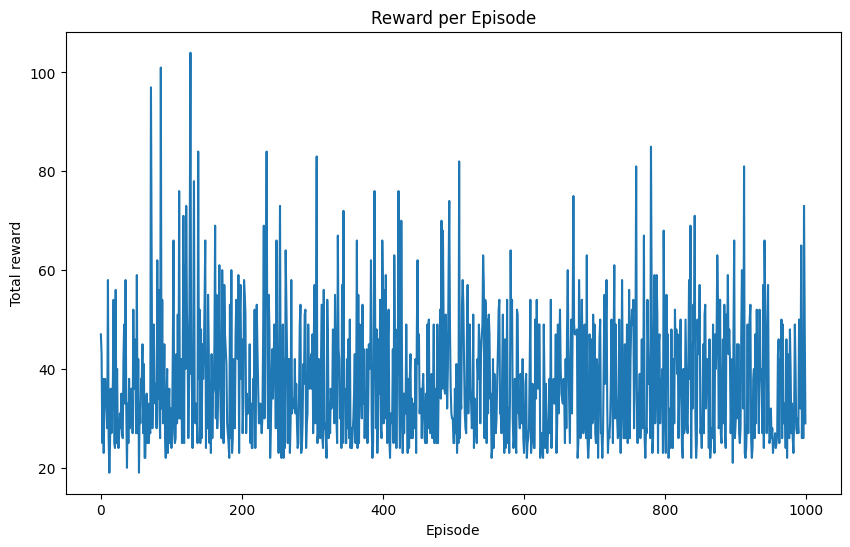

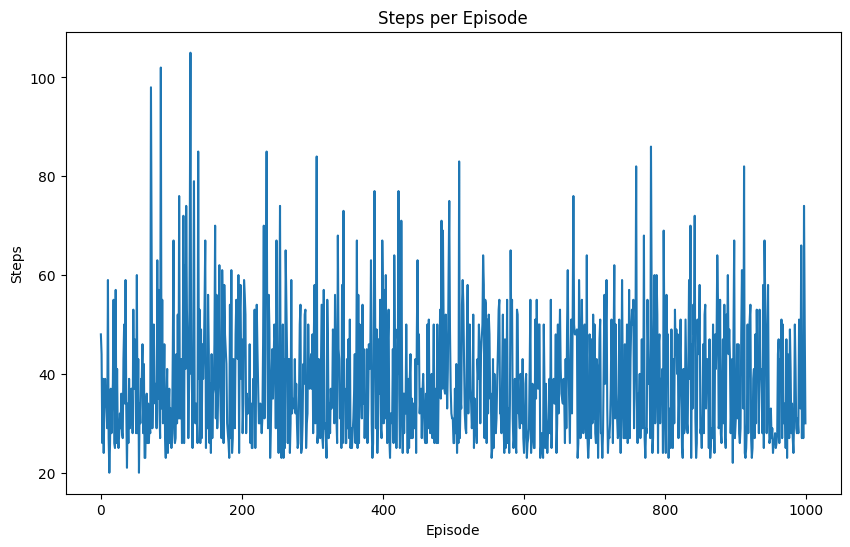

Evaluation of trained Q-Learning Agent performances started ...
Evaluation of trained Q-Learning Agent performances finished.


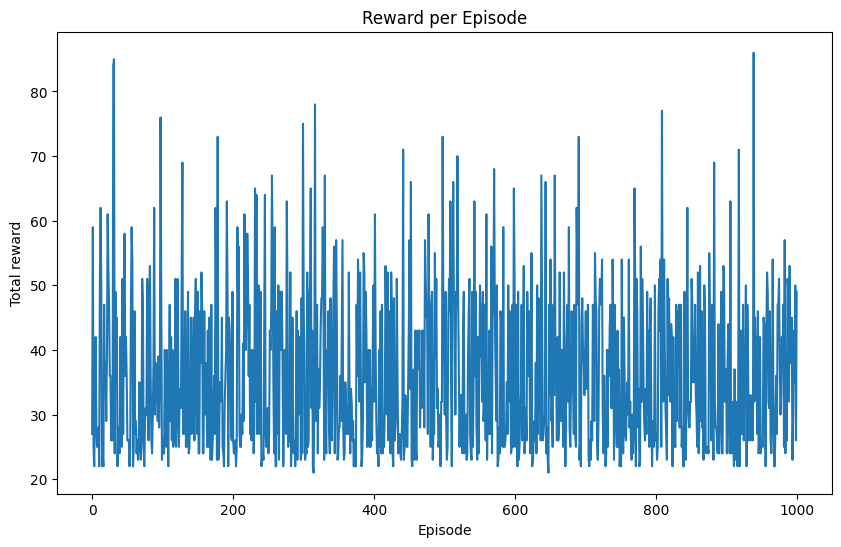

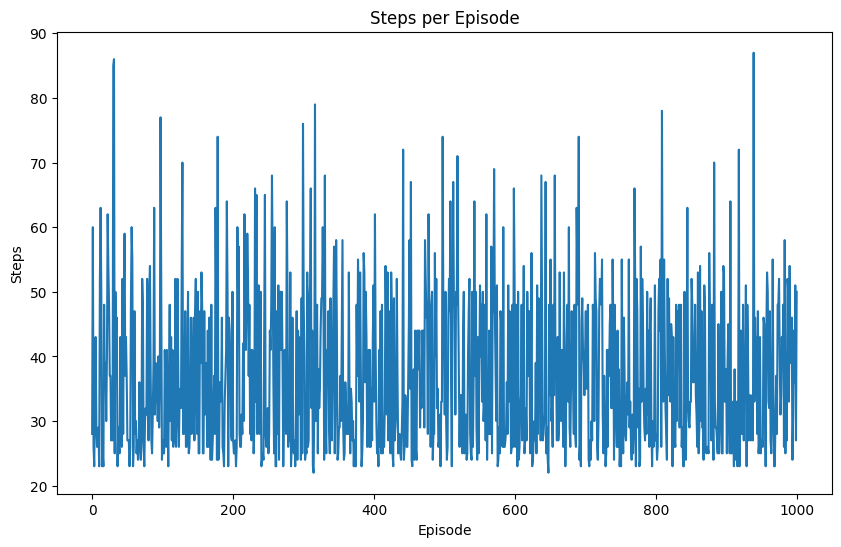

Successfull episodes: 0


In [101]:
# Define constants
FORCE_MAX = 10.0
EPISODES_MAX = 1000
STEPS_MAX = 500
GAMMA = 0.95
ALPHA = 0.1
EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995

if __name__ == "__main__":

    # Initialize model component
    model = CartPoleModel(T = 0.02)

    # Initialize state discretizer component
    state_discretizer = CartPoleStateDiscretizer(bins = (10, 10, 10, 10))

    # Initialize action space component
    action_space = ActionSpace(actions_type = 'binary', max_force = FORCE_MAX)

    # Initialize reward function component
    reward_function = RewardFunction(reward_type = 'gym_based', alpha = 2.0)

    # Initialize environment
    environment = CartPoleEnvironment(model, action_space, reward_function)

    # Initialize Q-Learning agent
    agent = QLearningAgent(action_size = action_space.action_num, 
                           gamma = GAMMA, 
                           epsilon = EPSILON,
                           epsilon_min = EPSILON_MIN, 
                           epsilon_decay = EPSILON_DECAY, 
                           alpha = ALPHA)

    # Train Q-Learning Agent
    print("Training of Q-Learning Agent started ...")
    training_rewards, training_steps= train_agent(environment = environment,
                                                   state_discretizer = state_discretizer,
                                                   agent = agent,
                                                   episodes_number=EPISODES_MAX,
                                                   max_steps=STEPS_MAX)
    
    print("Training of Q-Learning Agent finished.")

    plot_results(training_rewards, training_steps)

    print("Evaluation of trained Q-Learning Agent performances started ...")
    evaluation_reward, evaluation_steps, successfull = evaluate_agent(environment = environment,
                                                         state_discretizer = state_discretizer,
                                                         agent = agent,
                                                         episodes_number = EPISODES_MAX,
                                                         max_steps = STEPS_MAX)

    print("Evaluation of trained Q-Learning Agent performances finished.")

    plot_results(evaluation_reward, evaluation_steps)

    print(f"Successfull episodes: {successfull}")